# Etapa 3 — Baseline vs Thompson Sampling

Compara um baseline determinístico (regra fixa arbitrária, sem análise
prévia) com uma política adaptativa (Thompson Sampling Beta-Bernoulli),
avaliadas via método de replay (`datathon_mlet.replay.run_replay`) sobre o
histórico preparado na Etapa 2.

**Por que o baseline não é "o melhor canal histórico":** testamos isso
primeiro (ver histórico de execução) e o resultado foi um empate estatístico
— nenhuma política que precisa explorar consegue superar, na média, uma
regra que já começa sabendo a resposta certa (regret ≥ 0 é teoria básica de
bandit). O enunciado permite baseline = "regra fixa" **ou** "melhor braço
histórico" — são duas opções válidas. Usamos regra fixa arbitrária (sempre
`telephone`, como se fosse comportamento herdado sem base em dado), pra que
a política adaptativa tenha algo genuíno pra aprender e superar.

**Limitação metodológica:** o canal historicamente atribuído a cada
cliente não foi sorteado aleatoriamente (confundido com regime econômico —
ver `notebooks/01_eda.ipynb`, passo 6). O resultado abaixo é uma avaliação
offline sobre dado observacional, não uma medida causal do efeito do canal.

## Passo 1 — Carregar dado + baseline

Baseline determinístico usa uma regra fixa arbitrária — sempre `telephone`
(5,23% de conversão histórica, EDA passo 5), simulando um comportamento
herdado sem qualquer análise de dado por trás.

In [1]:
from pathlib import Path

from datathon_mlet.data_prep import load_clean_dataset, prepare_features
from datathon_mlet.policies import FixedPolicy

CLEAN_DATASET_PATH = Path("../data/processed/bank_marketing_clean.parquet")

df_clean = load_clean_dataset(CLEAN_DATASET_PATH)
prepared = prepare_features(df_clean)

baseline_policy = FixedPolicy(arm="telephone")
prepared.action.shape, prepared.reward.shape

((41188,), (41188,))

## Passo 2 — `run_replay` do baseline (1 seed)

Antes de escalar pra múltiplas seeds, ver o mecanismo uma vez só — `rounds_used` (rodadas aproveitadas) e `conversion_rate` nelas. Baseline sempre escolhe `telephone`, ~36,5% do histórico (15044/41188), então `rounds_used` deve ficar perto disso.

In [2]:
from datathon_mlet.replay import run_replay

baseline_result = run_replay(prepared.action, prepared.reward, baseline_policy, seed=0)
baseline_result.rounds_used, baseline_result.conversion_rate

(15044, 0.05231321457059293)

## Passo 3 — `run_replay` do Thompson Sampling (1 seed)

Mesma mecânica, mas a política aprende — começa sem saber qual braço é melhor (`Beta(1,1)` pra ambos), explora os dois e vai concentrando escolhas no que converte mais. Espera-se `conversion_rate` bem acima do baseline (~5,2%), migrando pra perto da taxa de `cellular` (~14,7%).

In [3]:
from datathon_mlet.policies import ThompsonSamplingPolicy

ts_policy = ThompsonSamplingPolicy(arms=["cellular", "telephone"])
ts_result = run_replay(prepared.action, prepared.reward, ts_policy, seed=0)
ts_result.rounds_used, ts_result.conversion_rate

(26035, 0.14703284040714423)

## Passo 4 — Múltiplas seeds + MLflow tracking

Regra do projeto: simulação estocástica precisa reportar variabilidade, não só 1 execução. Baseline não varia (é determinístico — a ordem de embaralhamento não muda quais linhas batem com `telephone`); só o Thompson Sampling precisa de várias seeds.

A partir daqui, a execução passa por `datathon_mlet.experiments.log_baseline_vs_thompson_sampling` (Etapa 7) — mesma lógica de replay, mas cada run grava `params`/`metrics` no MLflow. Suba o servidor antes (`docker compose up -d mlflow`) e acompanhe em http://localhost:5000.

In [4]:
import os

import mlflow
from dotenv import load_dotenv

from datathon_mlet.experiments import log_baseline_vs_thompson_sampling

N_SEEDS = 20
load_dotenv()
mlflow.set_tracking_uri(os.environ.get("MLFLOW_TRACKING_URI", "http://localhost:5000"))

results = log_baseline_vs_thompson_sampling(
    prepared.action,
    prepared.reward,
    arms=["cellular", "telephone"],
    baseline_arm="telephone",
    n_seeds=N_SEEDS,
)

(
    results.baseline.conversion_rate,
    results.ts_conversion_rates.mean(),
    results.ts_conversion_rates.std(),
)

🏃 View run baseline at: http://localhost:5000/#/experiments/1/runs/5ad7f01a2f344ddb8c75afd0b1e2dc94
🧪 View experiment at: http://localhost:5000/#/experiments/1


🏃 View run seed_0 at: http://localhost:5000/#/experiments/1/runs/0fa51ff6850f48ef80cc93b0a8d06872
🧪 View experiment at: http://localhost:5000/#/experiments/1


🏃 View run seed_1 at: http://localhost:5000/#/experiments/1/runs/3368de37f27b461f9bb6ba4d22be9e6b
🧪 View experiment at: http://localhost:5000/#/experiments/1


🏃 View run seed_2 at: http://localhost:5000/#/experiments/1/runs/0dfa54d5e9464f05a8b602c52108fe15
🧪 View experiment at: http://localhost:5000/#/experiments/1


🏃 View run seed_3 at: http://localhost:5000/#/experiments/1/runs/1039522938604b279a2f8b2be0fe1abf
🧪 View experiment at: http://localhost:5000/#/experiments/1


...

🏃 View run seed_16 at: http://localhost:5000/#/experiments/1/runs/d1d21ecf555f4eb3a74914a30b708989
🧪 View experiment at: http://localhost:5000/#/experiments/1


🏃 View run seed_17 at: http://localhost:5000/#/experiments/1/runs/446bcd939b074bbea3a023d3b9fb2528
🧪 View experiment at: http://localhost:5000/#/experiments/1


🏃 View run seed_18 at: http://localhost:5000/#/experiments/1/runs/1c663aeaea96452d97ad9cd078ece5a5
🧪 View experiment at: http://localhost:5000/#/experiments/1


🏃 View run seed_19 at: http://localhost:5000/#/experiments/1/runs/2acb7215d2a84945a1fee38f4189f0a1
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run thompson_sampling at: http://localhost:5000/#/experiments/1/runs/5cd61b0dd3d643adb70240f2c34fd205
🧪 View experiment at: http://localhost:5000/#/experiments/1


(0.05231321457059293,
 np.float64(0.1469089073212391),
 np.float64(0.00019102671470298954))

## Passo 5 — Gráfico comparativo

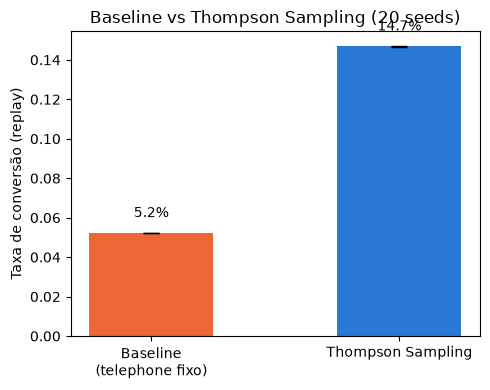

In [5]:
import matplotlib.pyplot as plt

labels = ["Baseline\n(telephone fixo)", "Thompson Sampling"]
means = [results.baseline.conversion_rate, results.ts_conversion_rates.mean()]
errors = [0.0, results.ts_conversion_rates.std()]
colors = ["#eb6834", "#2a78d6"]

plt.figure(figsize=(5, 4))
bars = plt.bar(labels, means, yerr=errors, capsize=6, color=colors, width=0.5)
for bar, mean in zip(bars, means):
    x = bar.get_x() + bar.get_width() / 2
    plt.text(x, mean + 0.008, f"{mean:.1%}", ha="center")
plt.ylabel("Taxa de conversão (replay)")
plt.title("Baseline vs Thompson Sampling (20 seeds)")
plt.tight_layout()
plt.show()

## Conclusão

- **Dados e recorte:** base Bank Marketing (`henriqueyamahata`), 41.188 clientes, contexto/ação/recompensa preparados na Etapa 2 (`prepare_features`).
- **Baseline:** regra fixa arbitrária — sempre `telephone` (sem análise prévia, simula decisão herdada).
- **Política adaptativa:** Thompson Sampling Beta-Bernoulli, prior `Beta(1,1)` por braço (`cellular`/`telephone`), sem uso de contexto (decisão registrada: bandit não-contextual, ver `docs/decisions/002-etapa3-baseline-e-replay.md`).
- **Métrica:** taxa de conversão (`cumulative_reward / rounds_used`) nas rodadas efetivamente aproveitadas pelo método de replay.
- **Protocolo:** replay (Li et al., 2011) — só conta rodada quando a ação escolhida pela política coincide com o canal real do cliente no histórico; sem contrafactual inventado.
- **Seeds:** baseline determinístico (1 execução, variância zero); Thompson Sampling em 20 seeds (0 a 19).
- **Resultado:** baseline = 5,23% (`rounds_used=15044`); Thompson Sampling = 14,69% ± 0,02 p.p. (média ± desvio-padrão em 20 seeds) — política adaptativa converte ~2,8× mais que o baseline.
- **Limitações:** (1) o canal historicamente atribuído não foi sorteado aleatoriamente — está confundido com regime econômico (EDA, passo 6) — então o resultado é avaliação offline sobre dado observacional, não uma medida causal do efeito do canal; (2) o replay descarta clientes cuja ação escolhida não bate com o histórico, reduzindo o tamanho efetivo de amostra (`rounds_used` < total); (3) bandit não-contextual — não personaliza por cliente, só aprende a taxa agregada por braço; (4) baseline "melhor canal histórico" (`cellular`) foi testado à parte e empata com o TS (14,70% vs 14,74%), resultado esperado pela teoria de bandit (nenhuma política de exploração supera, na média, um oráculo) — não reportado como o baseline principal por não deixar espaço pra a política adaptativa demonstrar aprendizado.